In [26]:
import sys
from pathlib import Path

cwd = Path.cwd()

if cwd.name == "notebooks":
    PROJECT_ROOT = cwd.parent
else:
    PROJECT_ROOT = cwd

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.analytics.volatility import (
    rolling_volatility,
    ewma_volatility,
    fit_garch,
    garch_parameter_summary,
    garch_one_step_forecast,
    rolling_garch_forecast,
)

from src.analytics.correlation import (
    rolling_correlation,
)

from src.analytics.dependence import (
    covariance_matrix,
    rolling_covariance_matrix,
    rolling_portfolio_volatility,
)

from src.analytics.regimes import (
    volatility_regime_thresholds,
    classify_volatility_regimes,
    regime_summary,
    compare_reference_periods,
)

pd.set_option(
    "display.max_columns",
    None,
)

pd.set_option(
    "display.float_format",
    lambda x: f"{x:.6f}",
)

print("Project root:", PROJECT_ROOT)
print("Imports successful.")

Project root: c:\Users\swaya\OneDrive\Documents\Multi-Asset-Market-Risk
Imports successful.


In [27]:
processed_dir = (
    PROJECT_ROOT
    / "data"
    / "processed"
)

prices_path = (
    processed_dir
    / "prices.csv"
)

returns_path = (
    processed_dir
    / "returns.csv"
)

prices = pd.read_csv(
    prices_path,
    index_col=0,
    parse_dates=True,
)

log_returns = pd.read_csv(
    returns_path,
    index_col=0,
    parse_dates=True,
)

print("Prices shape:", prices.shape)
print("Returns shape:", log_returns.shape)

print(
    "\nPrice date range:",
    prices.index.min().date(),
    "to",
    prices.index.max().date(),
)

print(
    "Return date range:",
    log_returns.index.min().date(),
    "to",
    log_returns.index.max().date(),
)

display(prices.head())
display(log_returns.head())

Prices shape: (5641, 3)
Returns shape: (5640, 3)

Price date range: 2005-01-03 to 2026-09-04
Return date range: 2005-01-04 to 2026-09-04


,SPY,EURUSD,TLT
Date,,,
2005-01-03,81.174606,1.347001,43.715534
2005-01-04,80.182701,1.328198,43.257393
2005-01-05,79.629372,1.328004,43.488926
2005-01-06,80.034241,1.318305,43.518478
2005-01-07,79.919533,1.306097,43.617016


,SPY,EURUSD,TLT
Date,,,
2005-01-04,-0.012295,-0.014058,-0.010535
2005-01-05,-0.006925,-0.000146,0.005338
2005-01-06,0.005072,-0.007330,0.000679
2005-01-07,-0.001434,-0.009303,0.002262
2005-01-10,0.004717,0.003743,0.001580


In [28]:
expected_assets = {
    "SPY",
    "EURUSD",
    "TLT",
}

assert expected_assets.issubset(
    set(prices.columns)
)

assert expected_assets.issubset(
    set(log_returns.columns)
)

assert prices.index.is_monotonic_increasing
assert log_returns.index.is_monotonic_increasing

assert prices.isna().sum().sum() == 0
assert log_returns.isna().sum().sum() == 0

assert np.isfinite(
    prices.to_numpy()
).all()

assert np.isfinite(
    log_returns.to_numpy()
).all()

print("All data validation checks passed.")

All data validation checks passed.


In [29]:
weights = pd.Series(
    {
        "SPY": 1 / 3,
        "EURUSD": 1 / 3,
        "TLT": 1 / 3,
    },
    name="Weight",
)

display(weights)
print("Weight sum:", weights.sum())

SPY      0.333333
EURUSD   0.333333
TLT      0.333333
Name: Weight, dtype: float64

Weight sum: 1.0


In [30]:
rolling_21 = rolling_volatility(
    log_returns,
    window=21,
    periods=252,
    annualize=True,
)

rolling_63 = rolling_volatility(
    log_returns,
    window=63,
    periods=252,
    annualize=True,
)

rolling_252 = rolling_volatility(
    log_returns,
    window=252,
    periods=252,
    annualize=True,
)

print("Rolling volatility calculated.")

Rolling volatility calculated.


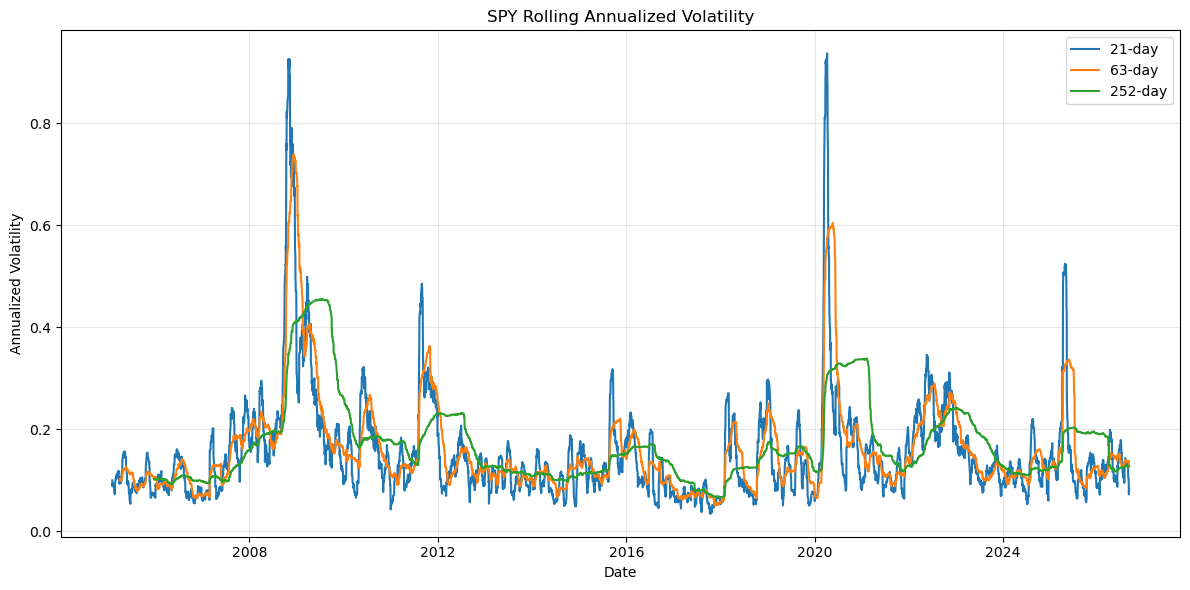

In [31]:
fig, ax = plt.subplots(
    figsize=(12, 6)
)

ax.plot(
    rolling_21["SPY"],
    label="21-day",
)

ax.plot(
    rolling_63["SPY"],
    label="63-day",
)

ax.plot(
    rolling_252["SPY"],
    label="252-day",
)

ax.set_title(
    "SPY Rolling Annualized Volatility"
)

ax.set_xlabel("Date")
ax.set_ylabel("Annualized Volatility")

ax.legend()

ax.grid(
    alpha=0.3
)

plt.tight_layout()

figures_dir = (
    PROJECT_ROOT
    / "results"
    / "figures"
)

figures_dir.mkdir(
    parents=True,
    exist_ok=True,
)

plt.savefig(
    figures_dir
    / "rolling_volatility.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

In [32]:
ewma_94 = {}

for asset in log_returns.columns:
    ewma_94[asset] = ewma_volatility(
        log_returns[asset],
        lam=0.94,
        periods=252,
    )

ewma_94 = pd.DataFrame(
    ewma_94,
    index=log_returns.index,
)

display(ewma_94.tail())

,SPY,EURUSD,TLT
Date,,,
2026-08-31,0.105877,0.042690,0.104474
2026-09-01,0.103310,0.047134,0.102696
2026-09-02,0.103688,0.046698,0.100826
2026-09-03,0.101992,0.045876,0.097828
2026-09-04,0.106855,0.044611,0.095018


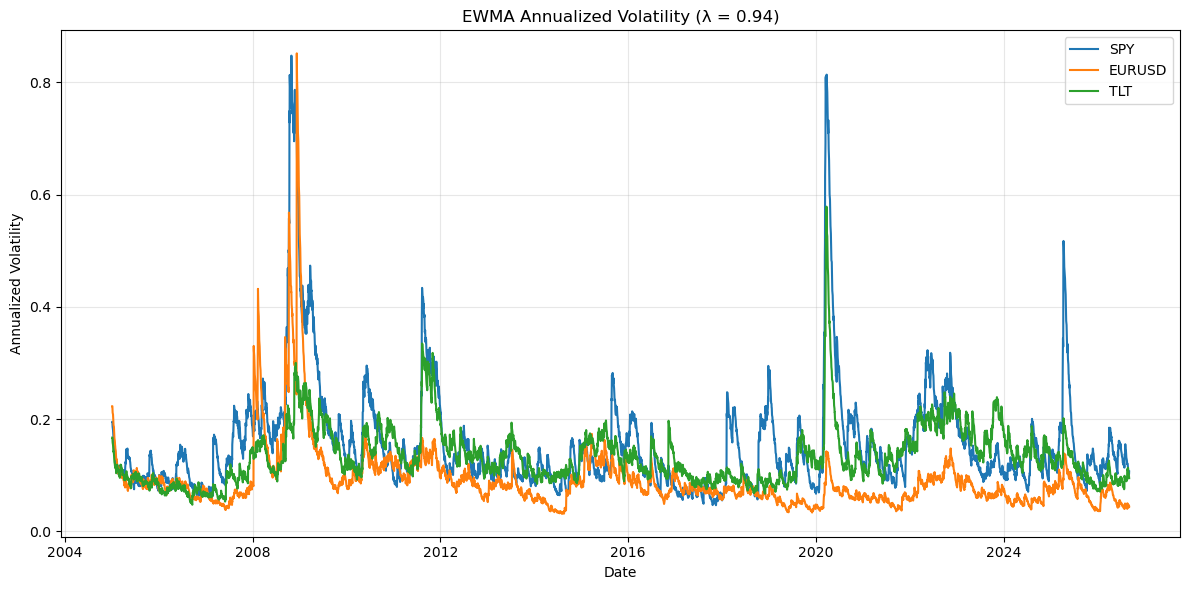

In [33]:
fig, ax = plt.subplots(
    figsize=(12, 6)
)

ax.plot(
    ewma_94["SPY"],
    label="SPY",
)

ax.plot(
    ewma_94["EURUSD"],
    label="EURUSD",
)

ax.plot(
    ewma_94["TLT"],
    label="TLT",
)

ax.set_title(
    "EWMA Annualized Volatility (λ = 0.94)"
)

ax.set_xlabel("Date")
ax.set_ylabel("Annualized Volatility")

ax.legend()

ax.grid(
    alpha=0.3
)

plt.tight_layout()

plt.savefig(
    figures_dir
    / "ewma_volatility.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

In [34]:
garch_models = {}
garch_parameters = {}

for asset in log_returns.columns:

    model, scaled_returns = fit_garch(
        log_returns[asset]
    )

    garch_models[asset] = model

    garch_parameters[asset] = (
        garch_parameter_summary(model)
    )

garch_parameters = pd.DataFrame(
    garch_parameters
).T

display(garch_parameters)

,omega_scaled,omega_decimal,alpha,beta,persistence
SPY,0.028688,0.000003,0.129688,0.844950,0.974638
EURUSD,0.001223,0.000000,0.047207,0.951720,0.998926
TLT,0.005465,0.000001,0.051998,0.941519,0.993516


In [35]:
garch_conditional_volatility = pd.DataFrame(
    index=log_returns.index
)

for asset, model in garch_models.items():

    conditional_volatility = (
        model.conditional_volatility
        / 100.0
        * np.sqrt(252)
    )

    garch_conditional_volatility[
        asset
    ] = conditional_volatility

display(
    garch_conditional_volatility.tail()
)

,SPY,EURUSD,TLT
Date,,,
2026-08-31,0.099421,0.049887,0.109695
2026-09-01,0.097633,0.052918,0.108296
2026-09-02,0.103369,0.052614,0.106819
2026-09-03,0.100965,0.052046,0.104358
2026-09-04,0.111314,0.051168,0.102056


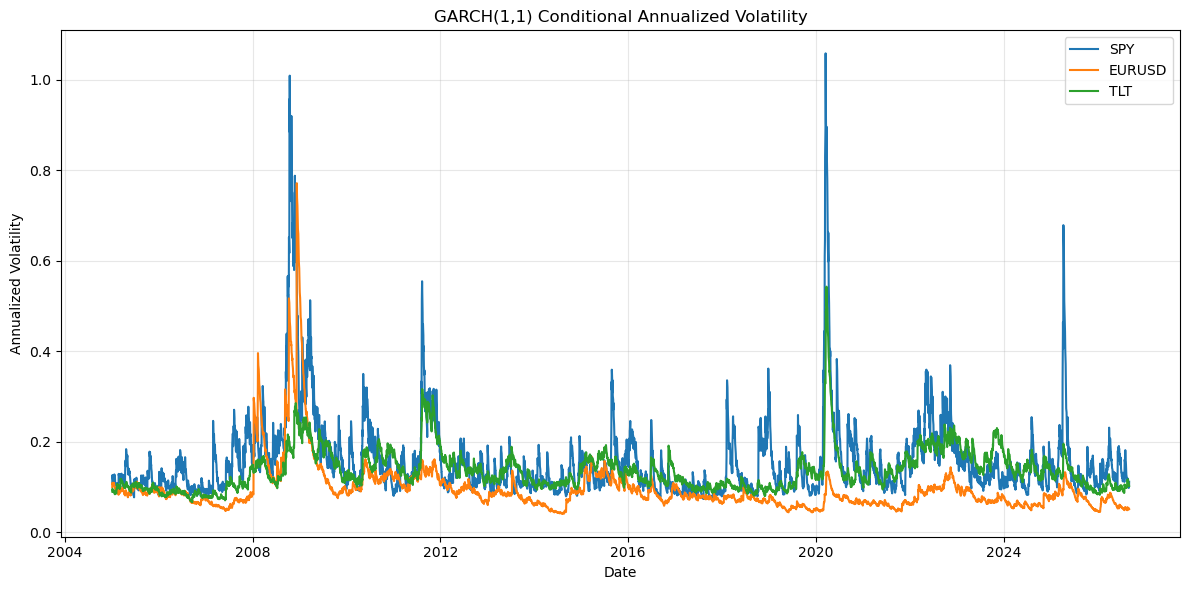

In [36]:
fig, ax = plt.subplots(
    figsize=(12, 6)
)

ax.plot(
    garch_conditional_volatility["SPY"],
    label="SPY",
)

ax.plot(
    garch_conditional_volatility["EURUSD"],
    label="EURUSD",
)

ax.plot(
    garch_conditional_volatility["TLT"],
    label="TLT",
)

ax.set_title(
    "GARCH(1,1) Conditional Annualized Volatility"
)

ax.set_xlabel("Date")
ax.set_ylabel("Annualized Volatility")

ax.legend()

ax.grid(
    alpha=0.3
)

plt.tight_layout()

plt.savefig(
    figures_dir
    / "garch_volatility.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

In [37]:
spy_returns = log_returns["SPY"]

spy_garch_forecast = rolling_garch_forecast(
    spy_returns,
    refit_frequency=21,
    min_train_size=756,
)

display(
    spy_garch_forecast.dropna().head()
)

display(
    spy_garch_forecast.dropna().tail()
)

Date
2007-11-28   0.197230
2007-11-29   0.247702
2007-11-30   0.225394
2007-12-03   0.212475
2007-12-04   0.197289
Name: GARCH_Forecast_Volatility, dtype: float64

Date
2026-08-31   0.093318
2026-09-01   0.089966
2026-09-02   0.099894
2026-09-03   0.098195
2026-09-04   0.121472
Name: GARCH_Forecast_Volatility, dtype: float64

,Rolling_21D,EWMA_94,GARCH_WalkForward
Date,,,
2026-08-31,0.102564,0.105877,0.093318
2026-09-01,0.094869,0.103310,0.089966
2026-09-02,0.072132,0.103688,0.099894
2026-09-03,0.080910,0.101992,0.098195
2026-09-04,0.081920,0.106855,0.121472


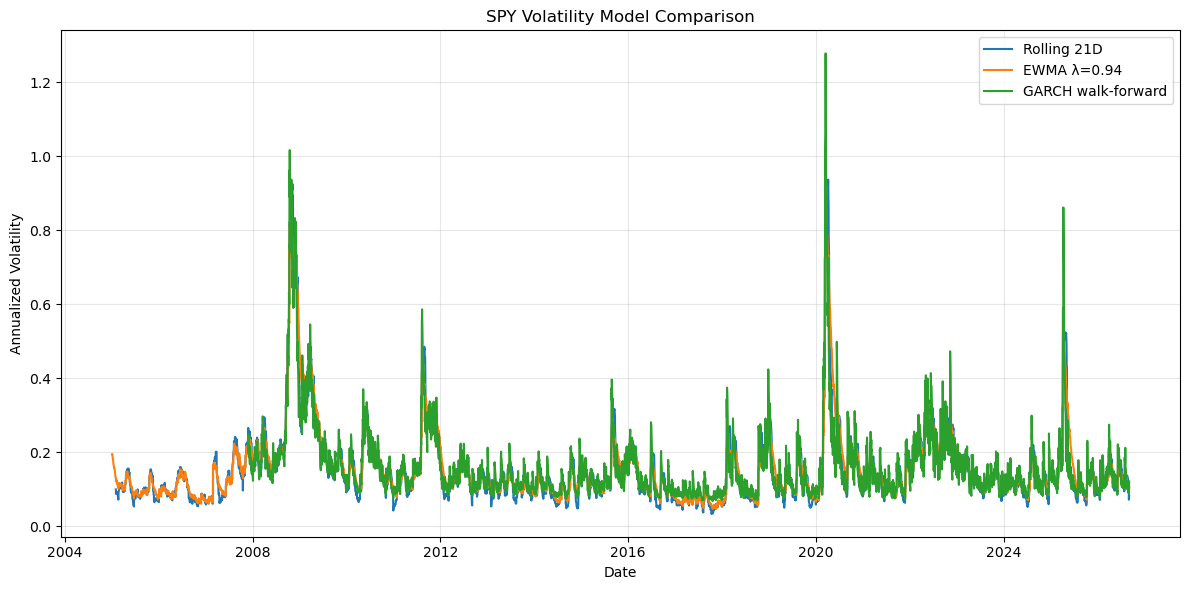

In [38]:
model_comparison = pd.DataFrame(
    {
        "Rolling_21D": rolling_21["SPY"],
        "EWMA_94": ewma_94["SPY"],
        "GARCH_WalkForward": spy_garch_forecast,
    }
)

display(
    model_comparison.tail()
)

fig, ax = plt.subplots(
    figsize=(12, 6)
)

ax.plot(
    model_comparison["Rolling_21D"],
    label="Rolling 21D",
)

ax.plot(
    model_comparison["EWMA_94"],
    label="EWMA λ=0.94",
)

ax.plot(
    model_comparison["GARCH_WalkForward"],
    label="GARCH walk-forward",
)

ax.set_title(
    "SPY Volatility Model Comparison"
)

ax.set_xlabel("Date")
ax.set_ylabel("Annualized Volatility")

ax.legend()

ax.grid(
    alpha=0.3
)

plt.tight_layout()

plt.savefig(
    figures_dir
    / "volatility_model_comparison.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

In [39]:
spy_tlt_corr = rolling_correlation(
    log_returns,
    asset_x="SPY",
    asset_y="TLT",
    window=126,
)

spy_eurusd_corr = rolling_correlation(
    log_returns,
    asset_x="SPY",
    asset_y="EURUSD",
    window=126,
)

tlt_eurusd_corr = rolling_correlation(
    log_returns,
    asset_x="TLT",
    asset_y="EURUSD",
    window=126,
)

rolling_correlations = pd.DataFrame(
    {
        "SPY_TLT": spy_tlt_corr,
        "SPY_EURUSD": spy_eurusd_corr,
        "TLT_EURUSD": tlt_eurusd_corr,
    }
)

display(
    rolling_correlations.tail()
)

spy_tlt_corr = rolling_correlation(
    log_returns,
    asset_x="SPY",
    asset_y="TLT",
    window=126,
)

spy_eurusd_corr = rolling_correlation(
    log_returns,
    asset_x="SPY",
    asset_y="EURUSD",
    window=126,
)

tlt_eurusd_corr = rolling_correlation(
    log_returns,
    asset_x="TLT",
    asset_y="EURUSD",
    window=126,
)

rolling_correlations = pd.DataFrame(
    {
        "SPY_TLT": spy_tlt_corr,
        "SPY_EURUSD": spy_eurusd_corr,
        "TLT_EURUSD": tlt_eurusd_corr,
    }
)

display(
    rolling_correlations.tail()
)

,SPY_TLT,SPY_EURUSD,TLT_EURUSD
Date,,,
2026-08-31,0.436074,0.048194,-0.264926
2026-09-01,0.432983,0.058593,-0.249615
2026-09-02,0.434372,0.063567,-0.227177
2026-09-03,0.438120,0.060844,-0.234103
2026-09-04,0.438017,0.031874,-0.237521


,SPY_TLT,SPY_EURUSD,TLT_EURUSD
Date,,,
2026-08-31,0.436074,0.048194,-0.264926
2026-09-01,0.432983,0.058593,-0.249615
2026-09-02,0.434372,0.063567,-0.227177
2026-09-03,0.438120,0.060844,-0.234103
2026-09-04,0.438017,0.031874,-0.237521


Number of rolling covariance matrices: 5515


2026-08-31   0.005868
2026-09-01   0.005785
2026-09-02   0.005740
2026-09-03   0.005715
2026-09-04   0.005639
Name: SPY_TLT_Covariance, dtype: float64

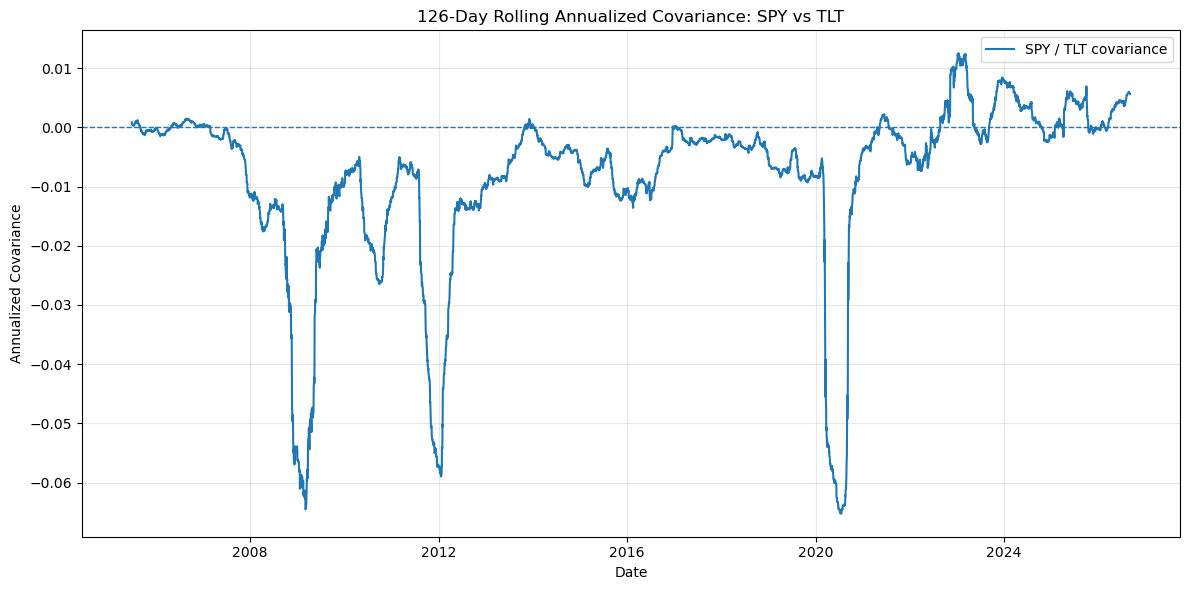

In [40]:
rolling_covariances = rolling_covariance_matrix(
    log_returns,
    window=126,
    annualize=True,
    periods=252,
)

print(
    "Number of rolling covariance matrices:",
    len(rolling_covariances),
)
spy_tlt_covariance = pd.Series(
    {
        date: matrix.loc["SPY", "TLT"]
        for date, matrix
        in rolling_covariances.items()
    },
    name="SPY_TLT_Covariance",
)

display(
    spy_tlt_covariance.tail()
)

fig, ax = plt.subplots(
    figsize=(12, 6)
)

ax.plot(
    spy_tlt_covariance,
    label="SPY / TLT covariance",
)

ax.axhline(
    0,
    linestyle="--",
    linewidth=1,
)

ax.set_title(
    "126-Day Rolling Annualized Covariance: SPY vs TLT"
)

ax.set_xlabel("Date")
ax.set_ylabel("Annualized Covariance")

ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    figures_dir
    / "rolling_covariance.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

Date
2026-08-31   0.067793
2026-09-01   0.067782
2026-09-02   0.067759
2026-09-03   0.067540
2026-09-04   0.066582
Name: Rolling_Portfolio_Volatility, dtype: float64

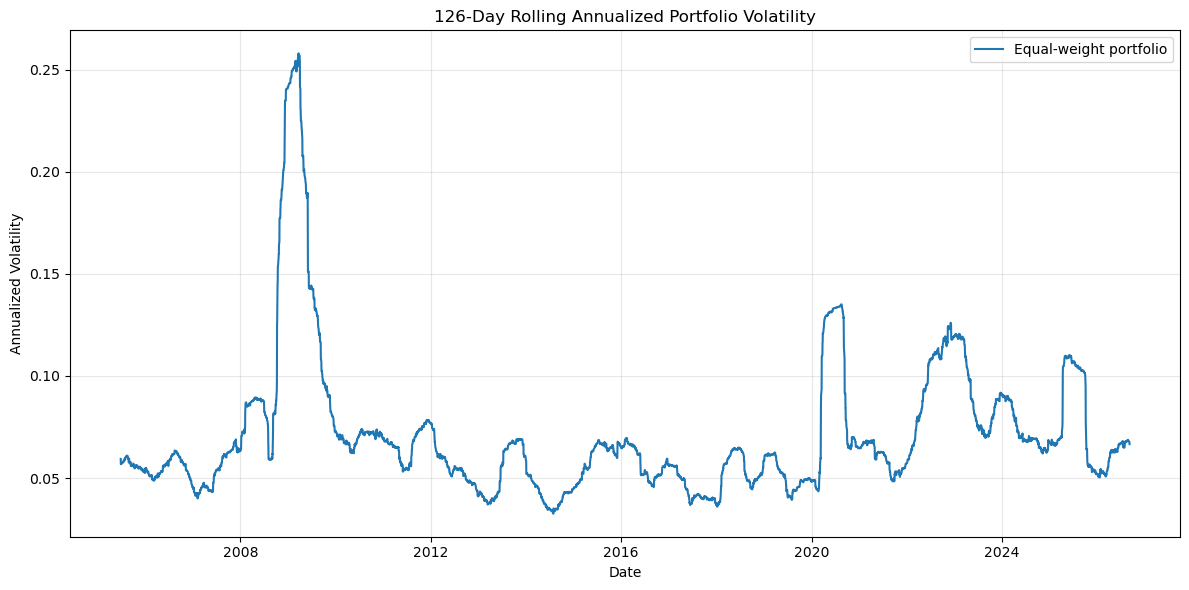

In [41]:
portfolio_rolling_vol = rolling_portfolio_volatility(
    log_returns,
    weights=weights,
    window=126,
    annualize=True,
    periods=252,
)

display(
    portfolio_rolling_vol.tail()
)
fig, ax = plt.subplots(
    figsize=(12, 6)
)

ax.plot(
    portfolio_rolling_vol,
    label="Equal-weight portfolio",
)

ax.set_title(
    "126-Day Rolling Annualized Portfolio Volatility"
)

ax.set_xlabel("Date")
ax.set_ylabel("Annualized Volatility")

ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    figures_dir
    / "rolling_portfolio_volatility.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

In [42]:
regime_thresholds = volatility_regime_thresholds(
    portfolio_rolling_vol
)

print("Regime thresholds:")
display(regime_thresholds)
portfolio_regimes = classify_volatility_regimes(
    portfolio_rolling_vol
)

display(
    portfolio_regimes.dropna().tail()
)

Regime thresholds:


low_threshold    0.055069
high_threshold   0.068419
dtype: float64

Date
2026-08-31    Medium
2026-09-01    Medium
2026-09-02    Medium
2026-09-03    Medium
2026-09-04    Medium
Name: Volatility_Regime, dtype: object

In [43]:
portfolio_regime_summary = regime_summary(
    portfolio_rolling_vol
)

display(
    portfolio_regime_summary
)

,count,percentage,mean_volatility,median_volatility,min_volatility,max_volatility
regime,,,,,,
Low,1838,33.327289,0.046983,0.048395,0.032528,0.055063
Medium,1838,33.327289,0.062468,0.063015,0.055069,0.068409
High,1839,33.345422,0.103228,0.088355,0.068419,0.258023


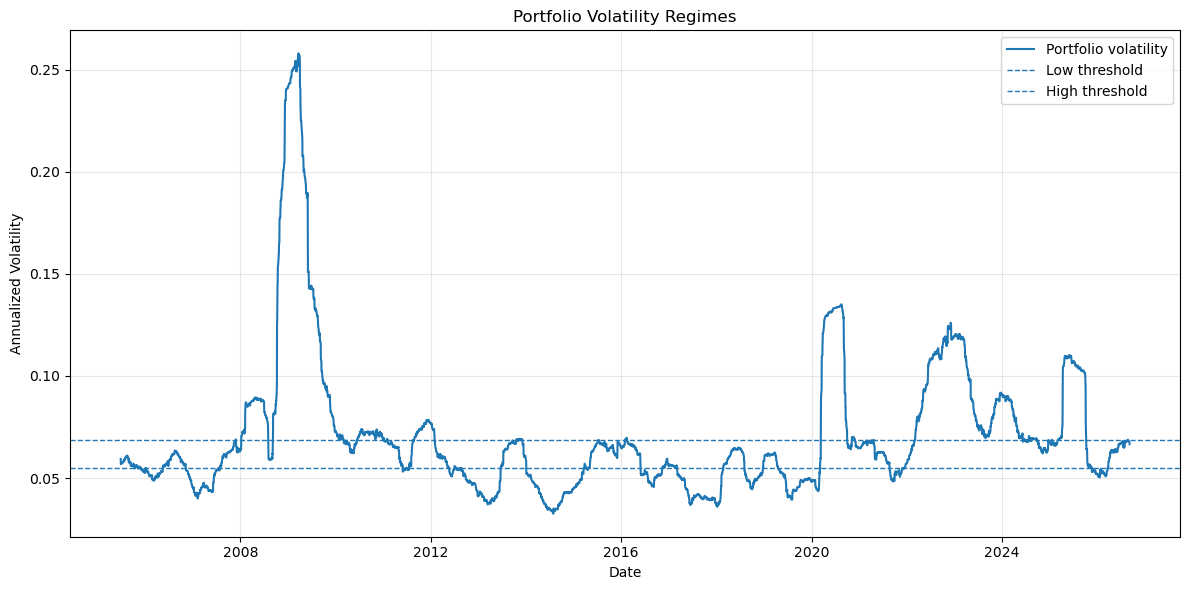

In [44]:
low_threshold = regime_thresholds[
    "low_threshold"
]

high_threshold = regime_thresholds[
    "high_threshold"
]

fig, ax = plt.subplots(
    figsize=(12, 6)
)

ax.plot(
    portfolio_rolling_vol,
    label="Portfolio volatility",
)

ax.axhline(
    low_threshold,
    linestyle="--",
    linewidth=1,
    label="Low threshold",
)

ax.axhline(
    high_threshold,
    linestyle="--",
    linewidth=1,
    label="High threshold",
)

ax.set_title(
    "Portfolio Volatility Regimes"
)

ax.set_xlabel("Date")
ax.set_ylabel("Annualized Volatility")

ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    figures_dir
    / "volatility_regimes.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

In [45]:
stress_period_comparison = compare_reference_periods(
    portfolio_rolling_vol
)

display(
    stress_period_comparison
)

,period,start,end,observations,mean_volatility,median_volatility,max_volatility,min_volatility
0,Global Financial Crisis,2008-01-01,2009-06-30,381,0.146158,0.092910,0.258023,0.058837
1,COVID-19 Shock,2020-02-01,2020-05-31,85,0.099446,0.122884,0.131541,0.043496
2,2022 Rate and Inflation Period,2022-01-01,2022-12-31,260,0.097718,0.108155,0.126062,0.057794


In [46]:
tables_dir = (
    PROJECT_ROOT
    / "results"
    / "tables"
)

tables_dir.mkdir(
    parents=True,
    exist_ok=True,
)

stress_period_comparison.to_csv(
    tables_dir
    / "stress_period_comparison.csv",
    index=False,
)

print(
    "Saved:",
    tables_dir
    / "stress_period_comparison.csv",
)

Saved: c:\Users\swaya\OneDrive\Documents\Multi-Asset-Market-Risk\results\tables\stress_period_comparison.csv


In [47]:
portfolio_regime_summary.to_csv(
    tables_dir
    / "regime_summary.csv"
)

print(
    "Saved:",
    tables_dir
    / "regime_summary.csv",
)

Saved: c:\Users\swaya\OneDrive\Documents\Multi-Asset-Market-Risk\results\tables\regime_summary.csv


In [48]:
garch_parameters.to_csv(
    tables_dir
    / "garch_parameters.csv"
)

print(
    "Saved:",
    tables_dir
    / "garch_parameters.csv",
)

Saved: c:\Users\swaya\OneDrive\Documents\Multi-Asset-Market-Risk\results\tables\garch_parameters.csv


In [49]:
model_comparison_clean = (
    model_comparison
    .dropna(how="all")
)

model_comparison_clean.to_csv(
    tables_dir
    / "volatility_model_comparison.csv"
)

print(
    "Saved:",
    tables_dir
    / "volatility_model_comparison.csv"
)

Saved: c:\Users\swaya\OneDrive\Documents\Multi-Asset-Market-Risk\results\tables\volatility_model_comparison.csv


In [50]:
final_summary = pd.DataFrame(
    {
        "Metric": [
            "Assets",
            "Observations",
            "Rolling volatility windows",
            "EWMA lambda",
            "GARCH model",
            "GARCH refit frequency",
            "Rolling correlation window",
            "Rolling covariance window",
            "Portfolio weighting",
            "Regime methodology",
        ],
        "Value": [
            ", ".join(log_returns.columns),
            len(log_returns),
            "21 / 63 / 252 days",
            "0.94",
            "GARCH(1,1)",
            "21 observations",
            "126 days",
            "126 days",
            "Equal weight",
            "33rd / 67th percentiles",
        ],
    }
)

display(final_summary)

final_summary.to_csv(
    tables_dir
    / "step9_summary.csv",
    index=False,
)

print(
    "\nStep 9 analytical outputs saved successfully."
)

,Metric,Value
0,Assets,"SPY, EURUSD, TLT"
1,Observations,5640
2,Rolling volatility windows,21 / 63 / 252 days
3,EWMA lambda,0.94
4,GARCH model,"GARCH(1,1)"
5,GARCH refit frequency,21 observations
6,Rolling correlation window,126 days
7,Rolling covariance window,126 days
8,Portfolio weighting,Equal weight
9,Regime methodology,33rd / 67th percentiles



Step 9 analytical outputs saved successfully.
